In [1]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Load the data

In [2]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [3]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format:
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

### Exercise 1 — warm-up questions

* **What does each *column* of $\tilde X$ represent?** Column 0 is a constant column of 1s (the "feature" that multiplies the offset $w_0$); column 1 holds the standardized height $x_{n1}$ of every person. In general, column $j$ is one *feature*, measured across all $N$ samples.
* **What does each *row* of $\tilde X$ represent?** One data example, i.e. one person: row $n$ is $[1, \; x_{n1}]$.
* **Why do we have 1's in $\tilde X$?** So that the offset $w_0$ can be folded into the matrix–vector product: $[1, x_{n1}] \cdot [w_0, w_1]^\top = w_0 + w_1 x_{n1}$. Without the column of 1s the model would be $y \approx w_1 x_{n1}$, a line forced through the origin.
* **Sizes for 3 people?** $\boldsymbol y$ would have shape $(3,)$ and $\tilde X$ shape $(3,2)$. $\tilde X_{32}$ (row 3, column 2, counting from 1 as in the sheet) is the height of the *third* person, $x_{31}$.
* **Do the sizes make sense?** `y.shape == (10000,)` and `tx.shape == (10000, 2)` — checked in the cell above.

### Exercise 1a — MSE in terms of $\boldsymbol e$

With $\boldsymbol e := \boldsymbol y - \tilde X \boldsymbol w$, the $n$-th entry is exactly $e_n = y_n - w_0 - w_1 x_{n1}$, so equation (2) becomes

$$\mathcal L(\boldsymbol w) \;=\; \frac{1}{2N}\sum_{n=1}^{N} e_n^2 \;=\; \frac{1}{2N}\,\boldsymbol e^\top \boldsymbol e \;=\; \frac{1}{2N}\,\lVert \boldsymbol y - \tilde X\boldsymbol w \rVert_2^2 .$$

The factor $\tfrac{1}{2}$ is a convention: it cancels the 2 that drops out when differentiating, giving the clean gradient of equation (7).

The MAE cost used from Section 5 on is defined without that factor, $\mathcal L_{\text{MAE}}(\boldsymbol w) = \frac1N \sum_n |e_n|$, so `compute_loss` takes a `loss_type` argument.

In [4]:
def compute_loss(y, tx, w, loss_type="mse"):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.
        loss_type: "mse" (equation (2), with the 1/2 factor) or "mae".

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # Compute the predictions
    pred = tx @ w
    # Compute the errors
    errors = y - pred
    if loss_type == "mse":
        # MSE as in eq. (2): 1/(2N) * sum(e_n^2) = 1/(2N) * e.T @ e
        loss = errors.dot(errors) / (2 * len(errors))
    elif loss_type == "mae":
        # Mean absolute error: 1/N * sum(|e_n|)
        loss = np.mean(np.abs(errors))
    else:
        raise ValueError("Invalid loss_type. Choose either 'mse' or 'mae'.")
    # ***************************************************
    return loss


compute_loss(y, tx, np.array([1, 2]))

np.float64(2694.483365887085)

Quick debugging check: the vector form of Ex. 1a must agree with the explicit sum.

In [5]:
w_test = np.array([1.0, 2.0])
explicit = sum((y[n] - w_test[0] - w_test[1] * tx[n, 1]) ** 2 for n in range(len(y))) / (
    2 * len(y)
)
print("explicit sum :", explicit)
print("vector form  :", compute_loss(y, tx, w_test))
assert np.isclose(explicit, compute_loss(y, tx, w_test))
print("MAE at the same w:", compute_loss(y, tx, w_test, loss_type="mae"))

explicit sum : 2694.483365887085
vector form  : 2694.483365887085
MAE at the same w: 72.29392200210516


# 2. Grid Search

Fill in the function `grid_search()` below:

In [6]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss for each combination of w0 and w1.
    for i, w0 in enumerate(grid_w0):
        for j, w1 in enumerate(grid_w1):
            w = np.array([w0, w1])
            losses[i, j] = compute_loss(y, tx, w)
    # ***************************************************
    return losses

Let us play with the grid search demo now!

Grid Search: loss*=18.793541019523108, w0*=71.42857142857142, w1*=15.306122448979579, execution time=0.079 seconds


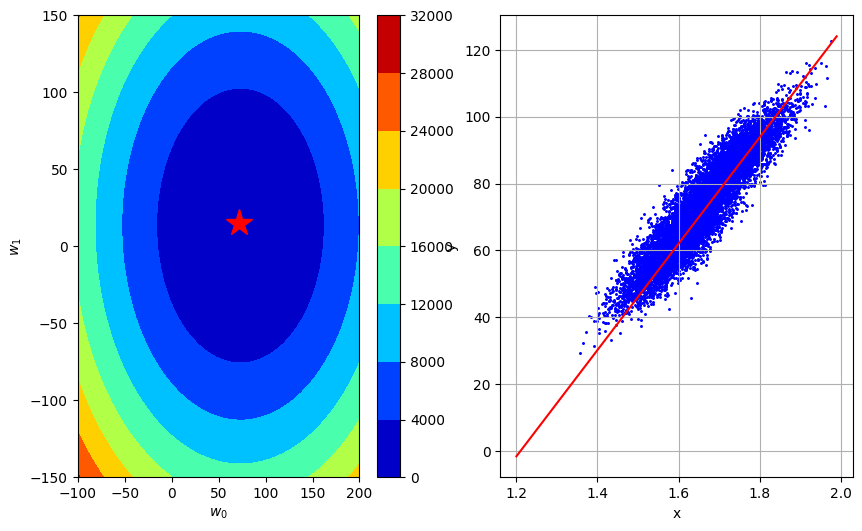

In [7]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=50)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

**Exercise 2b:** repeat the search with a grid spacing of **10** instead of 50, and compare the new fit to the old one.

num_intervals=10: loss*=42.4245, w0*=66.6667, w1*=16.6667


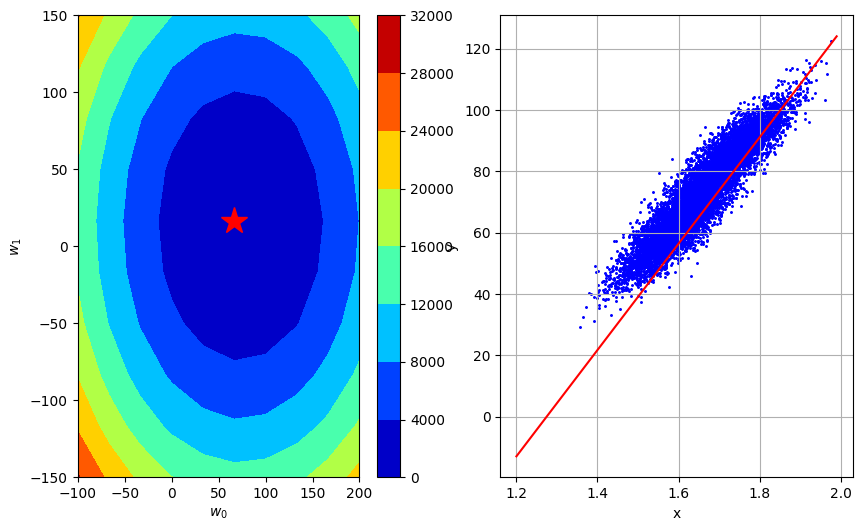

In [8]:
grid_w0_10, grid_w1_10 = generate_w(num_intervals=10)
grid_losses_10 = grid_search(y, tx, grid_w0_10, grid_w1_10)
loss_star_10, w0_star_10, w1_star_10 = get_best_parameters(
    grid_w0_10, grid_w1_10, grid_losses_10
)
print(
    "num_intervals=10: loss*={l:.4f}, w0*={w0:.4f}, w1*={w1:.4f}".format(
        l=loss_star_10, w0=w0_star_10, w1=w1_star_10
    )
)

fig = grid_visualization(
    grid_losses_10, grid_w0_10, grid_w1_10, mean_x, std_x, height, weight
)
fig.set_size_inches(10.0, 6.0)

How does the resolution of the grid trade off against the cost of the search?

In [9]:
# The closed-form least-squares solution, as a reference point for the grid results.
w_opt = np.linalg.solve(tx.T @ tx, tx.T @ y)
print("optimum      : w0*={:.4f}, w1*={:.4f}, loss={:.4f}\n".format(
    w_opt[0], w_opt[1], compute_loss(y, tx, w_opt)))

print(f"{'intervals':>10}{'spacing w0':>12}{'loss*':>12}{'w0*':>10}{'w1*':>10}"
      f"{'|w-w*|':>10}{'evals':>9}{'time [s]':>10}")
for num_intervals in [10, 20, 50, 100, 200]:
    gw0, gw1 = generate_w(num_intervals=num_intervals)
    start = datetime.datetime.now()
    gl = grid_search(y, tx, gw0, gw1)
    elapsed = (datetime.datetime.now() - start).total_seconds()
    l_star, a, b = get_best_parameters(gw0, gw1, gl)
    err = np.linalg.norm(np.array([a, b]) - w_opt)
    print(f"{num_intervals:>10}{gw0[1] - gw0[0]:>12.3f}{l_star:>12.4f}{a:>10.3f}"
          f"{b:>10.3f}{err:>10.3f}{num_intervals ** 2:>9}{elapsed:>10.3f}")

optimum      : w0*=73.2939, w1*=13.4797, loss=15.3859

 intervals  spacing w0       loss*       w0*       w1*    |w-w*|    evals  time [s]
        10      33.333     42.4245    66.667    16.667     7.354      100     0.002
        20      15.789     31.0580    73.684     7.895     5.599      400     0.006
        50       6.122     18.7935    71.429    15.306     2.611     2500     0.037


       100       3.030     15.5587    72.727    13.636     0.588    10000     0.148


       200       1.508     15.6101    73.367    12.814     0.670    40000     0.588


### Exercise 2b/2c — discussion

**Does this look like a good estimate? Why not?** With `num_intervals=50` the grid covers $w_0\in[-100,200]$ and $w_1\in[-150,150]$ in steps of about $6.1$. The best grid point lands near the true optimum but cannot equal it: grid search can never be more accurate than half a grid spacing, so the answer is quantized. The table above shows the distance $\lVert \hat{\boldsymbol w} - \boldsymbol w^\star\rVert$ shrinking as the grid gets finer — but *not* monotonically (200 intervals does slightly worse than 100 here). That is the nature of quantization: what matters is whether a grid point happens to fall close to the optimum, and refining the grid changes which points those are.

**What is the problem / why is the MSE plot not smooth?** The underlying cost is a perfectly smooth quadratic bowl. What we plot is not the cost, but the cost sampled at $50\times50$ points; `contourf` then interpolates linearly between those few samples, which is why the level sets look like polygons rather than ellipses. With `num_intervals=10` the effect is extreme — the contours become visibly angular and the recovered $\boldsymbol w$ is far off.

**Coarse grid or fine grid?** A fine grid is needed for an accurate fit; a coarse grid only localizes the region of the optimum.

**Effect on computational cost.** Grid search evaluates the loss $k^d$ times for $k$ values per dimension and $d$ parameters. Here $d=2$, so doubling the resolution *quadruples* the work — see the `evals` and `time` columns. With $d=2$ this is still cheap, but for even a handful of parameters it becomes hopeless (curse of dimensionality). That is exactly why we move to gradient descent, whose cost per step does not depend on the resolution we want.

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [10]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    # ***************************************************
    # Make prediction
    pred = tx @ w
    # Compute the errors
    errors = y - pred
    # Compute the gradient, eq. (7): -1/N * tx.T @ e
    gradient = 1 / len(y) * (-tx.T @ errors)
    # ***************************************************
    return gradient


compute_gradient(y, tx, np.array([100, 20]))

array([26.706078  ,  6.52028757])

First verify the gradient against a hand-computed / finite-difference value, then look at the two points asked for in Exercise 3b.

In [11]:
# Verification on a tiny hand-checkable example:
# y = [1, 3], tx = [[1, 0], [1, 1]], w = [0, 0]  =>  e = [1, 3]
# grad = -1/2 * [[1, 1], [0, 1]] @ [1, 3] = [-2, -1.5]
y_toy = np.array([1.0, 3.0])
tx_toy = np.array([[1.0, 0.0], [1.0, 1.0]])
print("by hand    :", np.array([-2.0, -1.5]))
print("computed   :", compute_gradient(y_toy, tx_toy, np.zeros(2)))


def finite_difference_gradient(y, tx, w, eps=1e-6):
    """Numerical gradient, used only to check compute_gradient."""
    grad = np.zeros_like(w, dtype=float)
    for i in range(len(w)):
        step = np.zeros_like(w, dtype=float)
        step[i] = eps
        grad[i] = (compute_loss(y, tx, w + step) - compute_loss(y, tx, w - step)) / (
            2 * eps
        )
    return grad


w_check = np.array([12.0, -7.0])
print("\nfinite diff:", finite_difference_gradient(y, tx, w_check))
print("analytic   :", compute_gradient(y, tx, w_check))
assert np.allclose(
    finite_difference_gradient(y, tx, w_check), compute_gradient(y, tx, w_check)
)

by hand    : [-2.  -1.5]
computed   : [-2.  -1.5]

finite diff: [-61.29392136 -20.47971202]
analytic   : [-61.293922   -20.47971243]


In [12]:
for w in [np.array([100.0, 20.0]), np.array([50.0, 10.0])]:
    grad = compute_gradient(y, tx, w)
    print(
        "w = ({:>6.1f}, {:>5.1f}) -> grad = ({:>8.4f}, {:>8.4f}), "
        "||grad|| = {:>7.4f}, distance to optimum = {:>7.4f}".format(
            w[0], w[1], grad[0], grad[1], np.linalg.norm(grad),
            np.linalg.norm(w - w_opt),
        )
    )

# Why the two coincide here: the Hessian of the MSE is (1/N) * tx.T @ tx,
# and the data was standardized, so this is (almost exactly) the identity.
print("\nHessian (1/N) X^T X =\n", tx.T @ tx / len(y))

w = ( 100.0,  20.0) -> grad = ( 26.7061,   6.5203), ||grad|| = 27.4905, distance to optimum = 27.4905
w = (  50.0,  10.0) -> grad = (-23.2939,  -3.4797), ||grad|| = 23.5524, distance to optimum = 23.5524

Hessian (1/N) X^T X =
 [[1.00000000e+00 3.81525922e-15]
 [3.81525922e-15 1.00000000e+00]]


### Exercise 3b — what do the gradient values tell us?

The gradient is bigger at $(100, 20)$ than at $(50, 10)$. For a quadratic cost, $\nabla\mathcal L(\boldsymbol w) = H(\boldsymbol w - \boldsymbol w^\star)$ with $H = \frac1N \tilde X^\top \tilde X$, so the gradient is a linear image of the *displacement from the minimum*: it is large far from the optimum and shrinks to zero at it. That is the picture from the hint — a quadratic bowl is steep far out and flat at the bottom.

Here the effect is unusually clean: because the input was standardized ($\bar x = 0$, $\operatorname{std}(x) = 1$), $H$ is the $2\times2$ identity, so the gradient is *exactly* the vector pointing from the optimum to $\boldsymbol w$, and $\lVert\nabla\mathcal L\rVert$ *is* the distance to the optimum. The update rule (8) then moves us a fraction $\gamma$ of the way to $\boldsymbol w^\star$ at every step — which is what makes the step-size behaviour in 3d so easy to read off.

Please fill in the functions `gradient_descent` below:

In [13]:
def gradient_descent(y, tx, initial_w, max_iters, gamma, verbose=True):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize
        verbose: whether to print the loss and parameters at each iteration

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        loss = compute_loss(y, tx, w, loss_type="mse")
        gradient = compute_gradient(y, tx, w)

        w = w - gamma * gradient
        # store w and loss
        ws.append(w)
        losses.append(loss)
        if verbose:
            print(
                "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                    bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
                )
            )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [14]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))
print("closed-form optimum: w0*={:.6f}, w1*={:.6f}".format(w_opt[0], w_opt[1]))
print("GD final           : w0 ={:.6f}, w1 ={:.6f}".format(gd_ws[-1][0], gd_ws[-1][1]))

GD iter. 0/49: loss=2792.2367127591656, w0=51.305745401473544, w1=9.43579870449258
GD iter. 1/49: loss=265.3024621089597, w0=66.69746902191565, w1=12.266538315840164
GD iter. 2/49: loss=37.878379550441096, w0=71.31498610804829, w1=13.115760199244406
GD iter. 3/49: loss=17.41021212017444, w0=72.70024123388808, w1=13.37052676426566
GD iter. 4/49: loss=15.568077051450455, w0=73.11581777164001, w1=13.446956733772033
GD iter. 5/49: loss=15.402284895265298, w0=73.2404907329656, w1=13.469885724623945
GD iter. 6/49: loss=15.387363601208627, w0=73.27789262136326, w1=13.476764421879517
GD iter. 7/49: loss=15.386020684743528, w0=73.28911318788256, w1=13.478828031056189
GD iter. 8/49: loss=15.385899822261676, w0=73.29247935783836, w1=13.47944711380919
GD iter. 9/49: loss=15.3858889446383, w0=73.2934892088251, w1=13.47963283863509
GD iter. 10/49: loss=15.385887965652193, w0=73.29379216412111, w1=13.479688556082861
GD iter. 11/49: loss=15.385887877543452, w0=73.29388305070992, w1=13.479705271317192


interactive(children=(BoundedIntText(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('…

<function __main__.plot_figure(n_iter)>

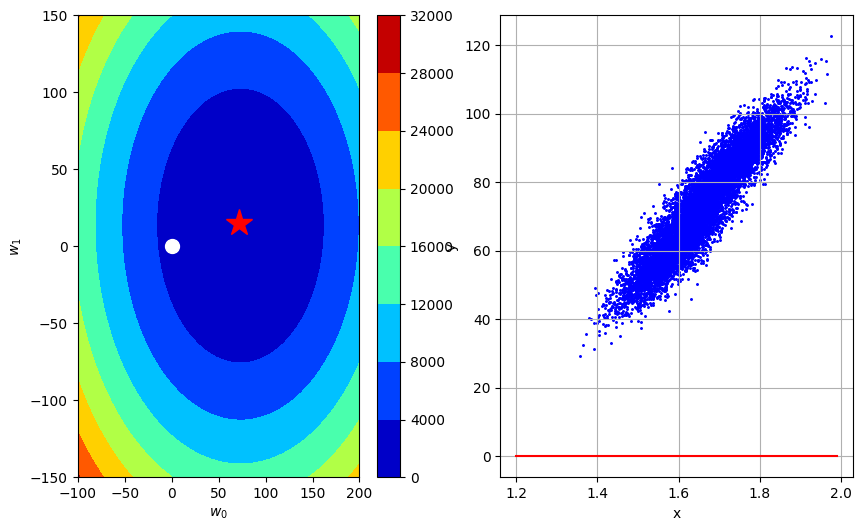

In [15]:
# Time Visualization
from ipywidgets import BoundedIntText, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=BoundedIntText(min=1, max=len(gd_ws), value=1))

### Exercise 3c — reading the iterations

* **Is the cost being minimized?** Yes, monotonically: with $\gamma = 0.7$ the loss falls from $\approx 2793$ to its minimum within a handful of iterations and then stops changing.
* **Is the algorithm converging, and how fast?** It converges *linearly* (geometrically): each step multiplies the distance to the optimum by $|1-\gamma| = 0.3$, so the error shrinks by an order of magnitude every ~2 iterations and stops changing at all after about 25. Compare this with grid search, which needed 2500 loss evaluations to get within 2.6 units of the optimum, while GD needs one gradient evaluation per step.
* **How good are the final $w_0, w_1$?** They agree with the closed-form least-squares solution $\boldsymbol w^\star = (\tilde X^\top \tilde X)^{-1}\tilde X^\top \boldsymbol y$ to ~15 digits (printed above). $w_0 \approx 73.29$ is the mean weight in kg, and $w_1 \approx 13.48$ is the weight change per standard deviation of height — note these are in *standardized* units, so $w_1$ is not kg/m.

**Exercise 3d:** the influence of the step size $\gamma$ and of the initialization.

In [16]:
step_sizes = [0.001, 0.01, 0.5, 1, 2, 2.5]
max_iters = 50
w_initial = np.array([0.0, 0.0])

gamma_runs = {}
print(f"{'gamma':>8}{'final loss':>16}{'w0':>16}{'w1':>16}{'behaviour':>16}")
for gamma in step_sizes:
    losses, ws = gradient_descent(y, tx, w_initial, max_iters, gamma, verbose=False)
    gamma_runs[gamma] = (losses, ws)
    final_loss = compute_loss(y, tx, ws[-1])
    dist = np.linalg.norm(ws[-1] - w_opt)
    if not np.isfinite(final_loss) or dist > 1e3:
        behaviour = "diverges"
    elif dist > 1e-6:
        behaviour = "not there yet" if abs(1 - gamma) < 1 else "oscillates"
    else:
        behaviour = "converged"
    print(f"{gamma:>8}{final_loss:>16.6g}{ws[-1][0]:>16.6g}{ws[-1][1]:>16.6g}"
          f"{behaviour:>16}")

   gamma      final loss              w0              w1       behaviour
   0.001         2527.86         3.57633        0.657734   not there yet
    0.01          1031.8         28.9507          5.3244   not there yet
     0.5         15.3859         73.2939         13.4797       converged
       1         15.3859         73.2939         13.4797       converged
       2         2792.24      -2.359e-12    -2.80238e-11      oscillates
     2.5     1.12896e+21    -4.67338e+10    -8.59495e+09        diverges


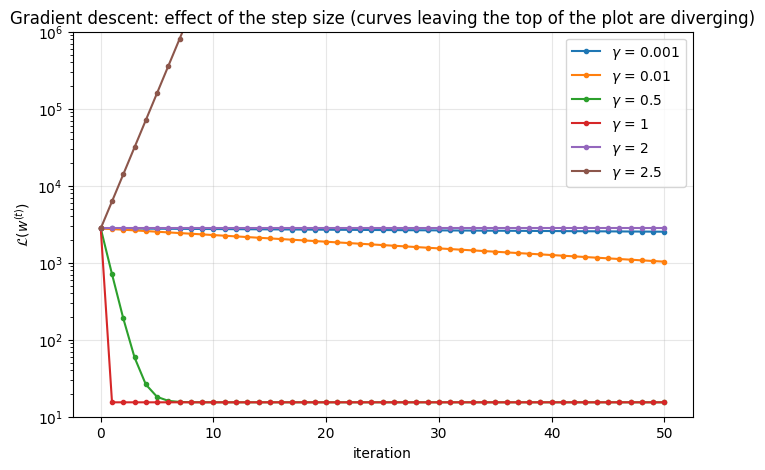

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
for gamma, (losses, ws) in gamma_runs.items():
    curve = [compute_loss(y, tx, w) for w in ws]
    ax.plot(curve, marker=".", label=r"$\gamma$ = {}".format(gamma))
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel(r"$\mathcal{L}(w^{(t)})$")
ax.set_title(
    "Gradient descent: effect of the step size "
    "(curves leaving the top of the plot are diverging)"
)
ax.set_ylim(1e1, 1e6)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

             initial w      final w0      final w1    dist. to optimum
(np.float64(0.0), np.float64(0.0))       72.9162       13.4102            0.384076
(np.float64(100.0), np.float64(10.0))       73.4316       13.4618            0.138801
(np.float64(-1000.0), np.float64(1000.0))       67.7624       18.5640             7.51318


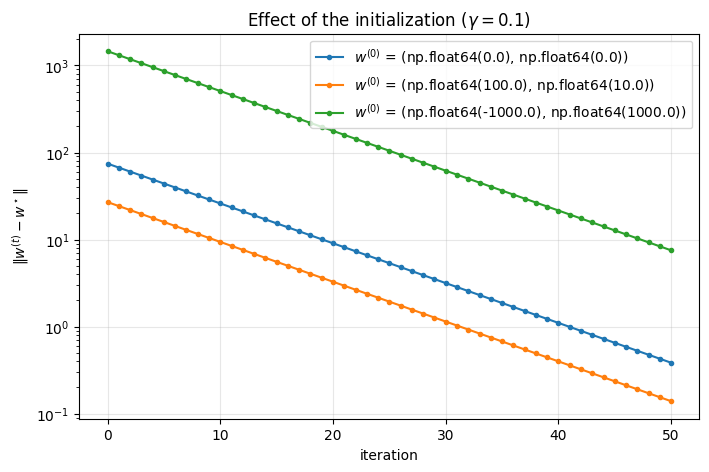

In [18]:
initializations = [np.array([0.0, 0.0]), np.array([100.0, 10.0]), np.array([-1000.0, 1000.0])]
gamma = 0.1
max_iters = 50

fig, ax = plt.subplots(figsize=(8, 5))
print(f"{'initial w':>22}{'final w0':>14}{'final w1':>14}{'dist. to optimum':>20}")
for w_init in initializations:
    losses, ws = gradient_descent(y, tx, w_init, max_iters, gamma, verbose=False)
    dist = np.linalg.norm(ws[-1] - w_opt)
    print(f"{str(tuple(w_init)):>22}{ws[-1][0]:>14.4f}{ws[-1][1]:>14.4f}{dist:>20.6g}")
    ax.plot(
        [np.linalg.norm(w - w_opt) for w in ws],
        marker=".",
        label=r"$w^{{(0)}}$ = {}".format(tuple(w_init)),
    )
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel(r"$\|w^{(t)} - w^\star\|$")
ax.set_title(r"Effect of the initialization ($\gamma = 0.1$)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### Exercise 3d — discussion

**Step size.** Because $H = I$ here, the error obeys $\boldsymbol w^{(t)} - \boldsymbol w^\star = (1-\gamma)^t (\boldsymbol w^{(0)} - \boldsymbol w^\star)$, and everything in the table follows from the factor $|1-\gamma|$:

| $\gamma$ | $\lvert 1-\gamma\rvert$ | what happens in 50 iterations |
|---|---|---|
| 0.001 | 0.999 | converges in theory, but after 50 steps we have barely moved — hopelessly slow |
| 0.01 | 0.99 | same story, still ~60 % of the initial error left |
| 0.5 | 0.5 | converges, error halved per step |
| 1 | 0 | converges in a **single** step — the perfect step size for this (standardized) problem |
| 2 | 1 | never converges: it jumps to the mirror image of the current point and oscillates forever at constant loss |
| 2.5 | 1.5 | **diverges**, the loss blows up geometrically |

The general condition is $\gamma < 2/\lambda_{\max}(H)$, which is $\gamma < 2$ here. Note that this threshold is a property of the *data*: standardizing the input is what made $\lambda_{\max} = 1$, and hence made a step size of order 1 the right choice. Without standardization the heights (~1.7) and the constant column (1) have very different scales, $H$ is badly conditioned, and only a much smaller $\gamma$ would be stable.

**Initialization.** With a fixed $\gamma = 0.1$ every initialization converges — the cost is convex, so there are no local minima to get stuck in, and the starting point only affects *how long* it takes. The error decays by a factor $0.9$ per iteration from wherever it starts, so starting at $(0,0)$ (distance $\approx 74$) is essentially converged after 50 steps, while starting at $(-1000, 1000)$ (distance $\approx 1460$) is not: $0.9^{50} \approx 0.005$ still leaves an error of $\approx 7.5$. This is the practical reason to initialize sensibly — it buys iterations, not correctness (for convex problems).

# 4. Stochastic gradient descent

In [19]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    # ***************************************************
    # Same formula as the full gradient, only evaluated on the mini-batch.
    pred = tx @ w
    errors = y - pred
    stoch_gradient = 1 / len(y) * (-tx.T @ errors)
    # ***************************************************
    return stoch_gradient


def stochastic_gradient_descent(
    y, tx, initial_w, batch_size, max_iters, gamma, verbose=True
):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize
        verbose: whether to print the loss and parameters at each iteration

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        for minibatch_y, minibatch_tx in batch_iter(y, tx, batch_size):
            loss = compute_loss(minibatch_y, minibatch_tx, w, loss_type="mse")
            stoch_gradient = compute_stoch_gradient(minibatch_y, minibatch_tx, w)

            w = w - gamma * stoch_gradient

            # store weights and losses
            ws.append(w)
            losses.append(loss)

        if verbose:
            print(
                "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                    bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
                )
            )
    return losses, ws

In [20]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 60

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
np.random.seed(2)
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=3513.9259083504876, w0=8.336398570731918, w1=5.481281069406047
SGD iter. 1/49: loss=2662.0937520177454, w0=15.615723422702537, w1=9.858330670395521
SGD iter. 2/49: loss=2030.5929891578314, w0=21.97275576131345, w1=14.360467492128759
SGD iter. 3/49: loss=1444.0378721217799, w0=27.32091658653276, w1=18.18695621762499
SGD iter. 4/49: loss=1212.694121998279, w0=32.187085562797954, w1=14.21971944912171
SGD iter. 5/49: loss=917.375302710448, w0=36.43231754685143, w1=17.100660616155732
SGD iter. 6/49: loss=718.2468827591218, w0=40.159531215111066, w1=14.483208124086207
SGD iter. 7/49: loss=521.4543065612069, w0=43.33279142944541, w1=12.43996404928421
SGD iter. 8/49: loss=385.5814236715663, w0=46.063250440224756, w1=10.140334543422213
SGD iter. 9/49: loss=484.27591769957303, w0=49.142084715240955, w1=11.632143236236361
SGD iter. 10/49: loss=384.65200888925744, w0=51.86693850919649, w1=13.73168126049818
SGD iter. 11/49: loss=281.53244877199455, w0=54.176389809775976, w1=15.

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

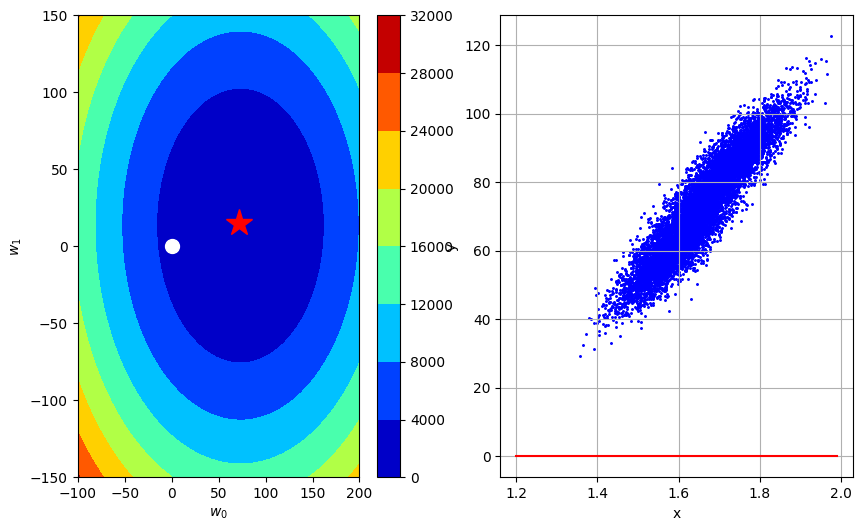

In [21]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

Let us compare the two procedures at the same step size and iteration count.

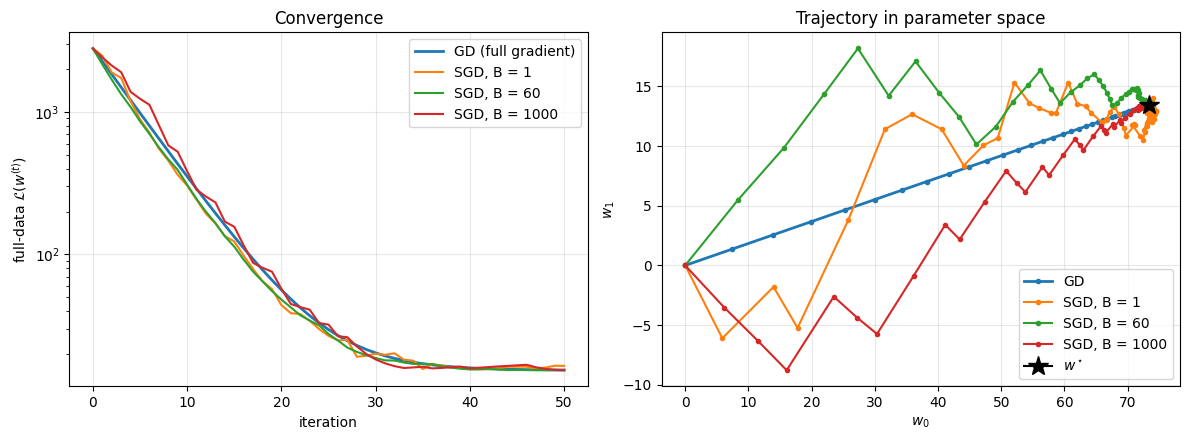

200 SGD iterations with B=    1: 0.0034 s
200 SGD iterations with B=   60: 0.0047 s
200 SGD iterations with B= 1000: 0.0050 s
200 GD  iterations with B=10000: 0.0100 s


In [22]:
max_iters = 50
gamma = 0.1
w_initial = np.array([0.0, 0.0])

gd_l, gd_w = gradient_descent(y, tx, w_initial, max_iters, gamma, verbose=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot([compute_loss(y, tx, w) for w in gd_w], label="GD (full gradient)", lw=2)
ax2.plot([w[0] for w in gd_w], [w[1] for w in gd_w], marker=".", label="GD", lw=2)

for batch_size in [1, 60, 1000]:
    np.random.seed(2)
    _, s_w = stochastic_gradient_descent(
        y, tx, w_initial, batch_size, max_iters, gamma, verbose=False
    )
    ax1.plot([compute_loss(y, tx, w) for w in s_w], label=f"SGD, B = {batch_size}")
    ax2.plot([w[0] for w in s_w], [w[1] for w in s_w], marker=".", label=f"SGD, B = {batch_size}")

ax1.set_yscale("log")
ax1.set_xlabel("iteration")
ax1.set_ylabel(r"full-data $\mathcal{L}(w^{(t)})$")
ax1.set_title("Convergence")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(w_opt[0], w_opt[1], marker="*", color="k", markersize=15, label=r"$w^\star$")
ax2.set_xlabel(r"$w_0$")
ax2.set_ylabel(r"$w_1$")
ax2.set_title("Trajectory in parameter space")
ax2.grid(alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

# Cost per iteration: SGD touches only B of the N rows.
for batch_size in [1, 60, 1000]:
    np.random.seed(2)
    start = datetime.datetime.now()
    stochastic_gradient_descent(y, tx, w_initial, batch_size, 200, gamma, verbose=False)
    t_sgd = (datetime.datetime.now() - start).total_seconds()
    print(f"200 SGD iterations with B={batch_size:>5}: {t_sgd:.4f} s")
start = datetime.datetime.now()
gradient_descent(y, tx, w_initial, 200, gamma, verbose=False)
print(f"200 GD  iterations with B={len(y):>5}: "
      f"{(datetime.datetime.now() - start).total_seconds():.4f} s")

### Exercise 4 — GD vs. SGD

* **Per-iteration cost.** GD looks at all $N = 10{,}000$ rows to take one step; SGD looks at $B$ of them, so the *arithmetic* per step is $N/B$ times cheaper. The measured times above are much less dramatic than that — 200 iterations take roughly 0.010 s for GD against 0.003 s for $B=1$, only ~3× — because at this problem size each iteration is dominated by Python and NumPy call overhead rather than by the two multiply-adds per row. The asymptotic argument is the real one: the full gradient is an *average*, a small sample already estimates the direction well enough to make progress, and on a data set large enough for the arithmetic to dominate (or one that does not fit in memory) that $N/B$ factor is what you actually get.
* **Quality of each step.** The stochastic gradient is an unbiased but noisy estimate of the true gradient. Early on, when we are far from $\boldsymbol w^\star$, the signal dominates the noise and SGD drops the loss just as fast as GD (see the left panel). Close to the optimum the signal vanishes but the noise does not, so the iterates stop converging and instead random-walk inside a "noise ball" whose radius grows with $\gamma$ and shrinks with $B$ — visible in the right panel as a cloud around the star, and in the printed per-iteration losses as numbers that jump around instead of decreasing monotonically.
* **Monotonicity.** GD's loss decreases at every step (for a well-chosen $\gamma$); SGD's does not, and the loss it *prints* is a mini-batch loss, which is noisy in its own right — a mini-batch of 60 people can look easy or hard by luck.
* **Practical consequence.** SGD gets you to a decent solution much faster; getting a high-accuracy solution requires decaying the step size (or growing the batch), which is what schedulers in real training loops do.

# 5. Effect of Outliers and MAE Cost Function

First reload a sub-sample of the data (no outliers yet), as asked in Exercise 5, and plot it.

In [23]:
import datetime
from helpers import *

# ***************************************************
# Sub-sampled data, WITHOUT outliers
height_s, weight_s, gender_s = load_data(sub_sample=True, add_outlier=False)
x_s, mean_x_s, std_x_s = standardize(height_s)
y_s, tx_s = build_model_data(x_s, weight_s)

# Same sub-sample, WITH the two outlier points (weights entered in pounds)
height_o, weight_o, gender_o = load_data(sub_sample=True, add_outlier=True)
x_o, mean_x_o, std_x_o = standardize(height_o)
y_o, tx_o = build_model_data(x_o, weight_o)
# ***************************************************

print("without outliers:", y_s.shape, tx_s.shape)
print("with outliers   :", y_o.shape, tx_o.shape)
print("the two extra points:", list(zip(height_o[-2:], weight_o[-2:])))

without outliers: (200,) (200, 2)
with outliers   : (202,) (202, 2)
the two extra points: [(np.float64(1.1), np.float64(113.43612334801762)), (np.float64(1.2), np.float64(121.80616740088105))]


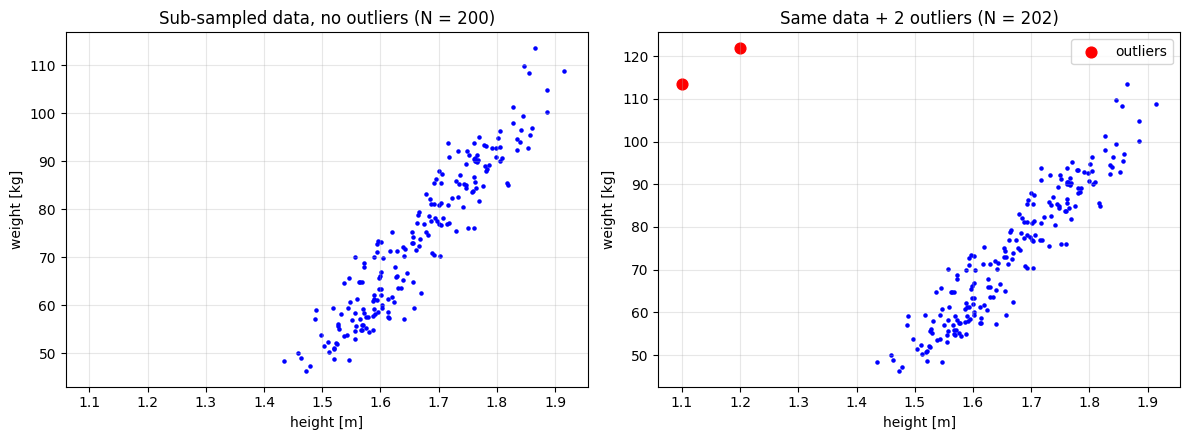

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
ax1.scatter(height_s, weight_s, marker=".", color="b", s=20)
ax1.set_title(f"Sub-sampled data, no outliers (N = {len(y_s)})")
ax2.scatter(height_o, weight_o, marker=".", color="b", s=20)
ax2.scatter(height_o[-2:], weight_o[-2:], marker="o", color="r", s=60, label="outliers")
ax2.set_title(f"Same data + 2 outliers (N = {len(y_o)})")
ax2.legend()
for ax in (ax1, ax2):
    ax.set_xlabel("height [m]")
    ax.set_ylabel("weight [kg]")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Now fit the MSE model to both versions of the data, using gradient descent.

In [25]:
max_iters = 100
gamma = 0.7
w_initial = np.array([0.0, 0.0])

_, ws_clean = gradient_descent(y_s, tx_s, w_initial, max_iters, gamma, verbose=False)
w_mse_clean = ws_clean[-1]

gd_losses_o, gd_ws_o = gradient_descent(
    y_o, tx_o, w_initial, max_iters, gamma, verbose=False
)
w_mse_outlier = gd_ws_o[-1]

print("MSE fit without outliers: w0={:.4f}, w1={:.4f}".format(*w_mse_clean))
print("MSE fit with outliers   : w0={:.4f}, w1={:.4f}".format(*w_mse_outlier))

MSE fit without outliers: w0=73.6323, w1=14.4757
MSE fit with outliers   : w0=74.0678, w1=11.0349


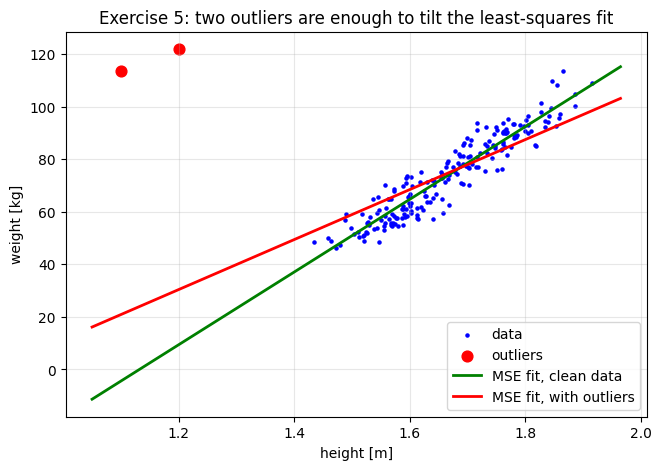

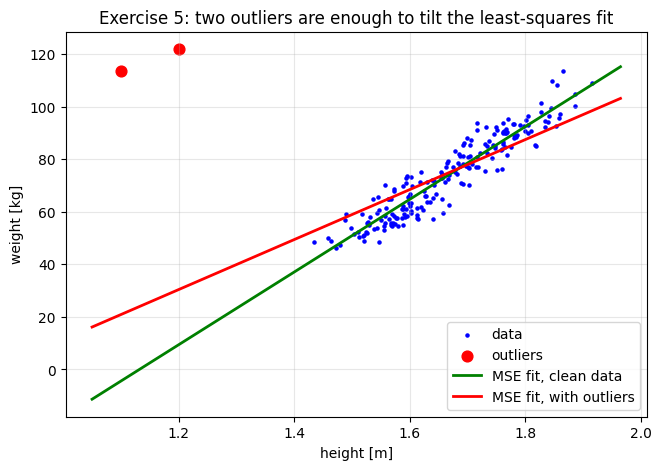

In [26]:
def plot_fits(height, weight, fits, title, outliers=0):
    """Scatter the data and overlay one regression line per (label, w, mean, std)."""
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.scatter(height, weight, marker=".", color="b", s=20, label="data")
    if outliers:
        ax.scatter(
            height[-outliers:], weight[-outliers:], marker="o", color="r", s=60,
            label="outliers",
        )
    grid_x = np.linspace(min(height) - 0.05, max(height) + 0.05, 100)
    for label, w, mean, std, style in fits:
        ax.plot(grid_x, w[0] + w[1] * (grid_x - mean) / std, style, lw=2, label=label)
    ax.set_xlabel("height [m]")
    ax.set_ylabel("weight [kg]")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()
    return fig


plot_fits(
    height_o,
    weight_o,
    [
        ("MSE fit, clean data", w_mse_clean, mean_x_s, std_x_s, "g-"),
        ("MSE fit, with outliers", w_mse_outlier, mean_x_o, std_x_o, "r-"),
    ],
    "Exercise 5: two outliers are enough to tilt the least-squares fit",
    outliers=2,
)

interactive(children=(IntSlider(value=1, description='n_iter', max=101, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

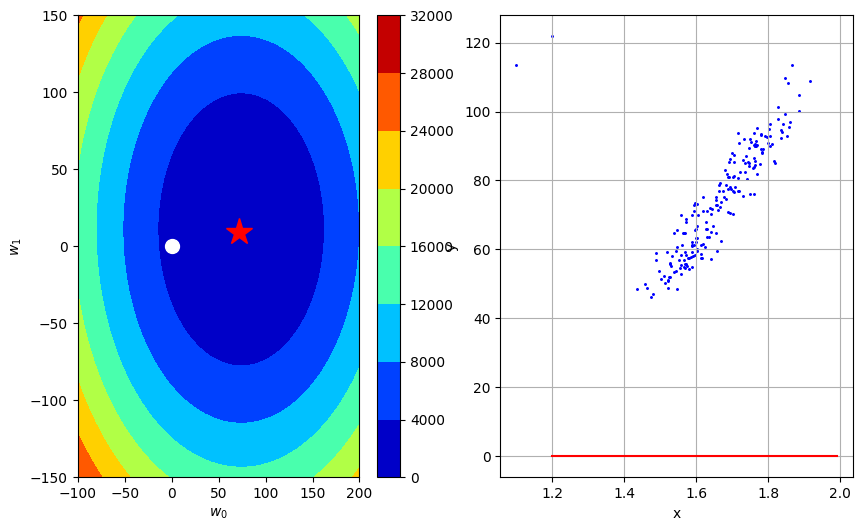

In [27]:
# Contour + trajectory view for the data set with outliers.
grid_losses_o = grid_search(y_o, tx_o, grid_w0, grid_w1)

from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses_o,
        gd_ws_o,
        grid_losses_o,
        grid_w0,
        grid_w1,
        mean_x_o,
        std_x_o,
        height_o,
        weight_o,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws_o)))

### Exercise 5 — discussion

The sub-sample has $N = 200$ points and gives a clean, tight linear relationship; the MSE fit through it is good. The two "outliers" are people of height 1.1 m and 1.2 m whose weight was left in pounds, so they sit at $\approx 113$ kg and $\approx 122$ kg — far above the trend, and at the *left* edge of the height range, which is the worst possible place for them (high leverage).

**Does it look like a good fit?** No. Adding just 2 points out of 202 (1 % of the data) visibly rotates and lifts the line: in the plot above the red line sits above the green one on the left and dips below it on the right, so the model now over-predicts the weight of short people and under-predicts the weight of tall people — it fits nobody well. Averaged over the height range it is off by 5.2 kg from the clean-data fit (measured in Exercise 6b below). Compare the fitted parameters only through the plot, not directly: adding the outliers changes `mean_x`/`std_x`, so $w_1$ is expressed in a different unit in the two fits.

**Why is MSE so sensitive?** The residual of each point enters the cost *squared*, so a point that is 50 kg off contributes 2500 times more than a point that is 1 kg off. The optimum is pulled toward whatever reduces those few huge squared residuals, at everyone else's expense. Equivalently: the least-squares estimate is a weighted mean, and means are not robust. A robust cost such as the MAE, where each point contributes in proportion to $|e_n|$ (and its *subgradient* contributes only $\pm 1$, regardless of how far off it is), is the fix — that is Section 6.

# 6. Subgradient descent

### Exercise 6a — a subgradient of the MAE

Write the cost as $\mathcal L(\boldsymbol w) = h(q(\boldsymbol w))$ with $q_n(\boldsymbol w) = y_n - \tilde{\boldsymbol x}_n^\top \boldsymbol w = e_n$ (differentiable, $\nabla q_n = -\tilde{\boldsymbol x}_n$) and $h(e) = \frac1N\sum_n |e_n|$. The absolute value has subdifferential

$$\partial |e| = \begin{cases} \{+1\} & e > 0\\ [-1, 1] & e = 0 \\ \{-1\} & e < 0\end{cases}$$

so by the chain rule given in the hint,

$$\partial \mathcal L(\boldsymbol w) \;=\; -\frac1N \sum_{n=1}^{N} s_n\,\tilde{\boldsymbol x}_n \;=\; -\frac1N \tilde X^\top \boldsymbol s, \qquad s_n \in \partial|e_n| .$$

Any choice of $s_n \in [-1,1]$ at a point where $e_n = 0$ gives a valid subgradient. Implementing $\boldsymbol s = \operatorname{sign}(\boldsymbol e)$ picks $s_n = 0$ there, which is legal since $0 \in [-1,1]$.

Note what this means for robustness: an outlier contributes $\pm\tilde{\boldsymbol x}_n$ to the subgradient no matter how far away it is, whereas under the MSE it contributes $e_n \tilde{\boldsymbol x}_n$, which grows without bound.

In [28]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    # ***************************************************
    pred = tx @ w
    errors = y - pred
    # np.sign picks s_n = 0 at the non-differentiable points e_n = 0, which is a
    # valid element of the subdifferential [-1, 1].
    subgradient = -1 / len(y) * (tx.T @ np.sign(errors))
    # ***************************************************
    return subgradient

In [29]:
# Check against a finite difference away from any kink: there the MAE is smooth
# and the subgradient must coincide with the ordinary gradient.
def finite_difference_mae(y, tx, w, eps=1e-6):
    grad = np.zeros_like(w, dtype=float)
    for i in range(len(w)):
        step = np.zeros_like(w, dtype=float)
        step[i] = eps
        grad[i] = (
            compute_loss(y, tx, w + step, "mae") - compute_loss(y, tx, w - step, "mae")
        ) / (2 * eps)
    return grad


w_check = np.array([60.0, 8.0])
print("finite diff:", finite_difference_mae(y_o, tx_o, w_check))
print("subgradient:", compute_subgradient_mae(y_o, tx_o, w_check))

finite diff: [-0.92079208 -0.06755097]
subgradient: [-0.92079208 -0.06755097]


In [30]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma, decreasing_gamma=False, verbose=True):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize
        decreasing_gamma: if True use the step size gamma / sqrt(t + 1)
        verbose: whether to print the loss and parameters at each iteration

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        loss = compute_loss(y, tx, w, loss_type="mae")
        subgradient = compute_subgradient_mae(y, tx, w)

        step = gamma / np.sqrt(n_iter + 1) if decreasing_gamma else gamma
        w = w - step * subgradient

        ws.append(w)
        losses.append(loss)
        if verbose:
            print(
                "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                    bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
                )
            )

    return losses, ws

In [31]:
# Define the parameters of the algorithm.
max_iters = 1000
gamma = 2.0

# Initialization
w_initial = np.array([0.0, 0.0])

# Start SubGD on the data set that contains the outliers.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(
    y_o, tx_o, w_initial, max_iters, gamma, decreasing_gamma=True, verbose=False
)
end_time = datetime.datetime.now()
w_mae_outlier = subgd_ws[-1]

exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))
print("MAE fit with outliers: w0={:.4f}, w1={:.4f}".format(*w_mae_outlier))
print("final MAE  = {:.4f}".format(compute_loss(y_o, tx_o, w_mae_outlier, "mae")))
print("MAE of the MSE fit = {:.4f}".format(
    compute_loss(y_o, tx_o, w_mse_outlier, "mae")))

# Did we ever land exactly on a non-differentiable point (some e_n == 0)?
kinks = sum(np.any(y_o - tx_o @ w == 0) for w in subgd_ws)
print("iterations that hit a non-differentiable point:", kinks, "/", len(subgd_ws))

SubGD: execution time=0.011 seconds
MAE fit with outliers: w0=72.6825, w1=15.8495
final MAE  = 5.3112
MAE of the MSE fit = 6.6374
iterations that hit a non-differentiable point: 0 / 1001


interactive(children=(IntSlider(value=1, description='n_iter', max=1001, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_figure(n_iter)>

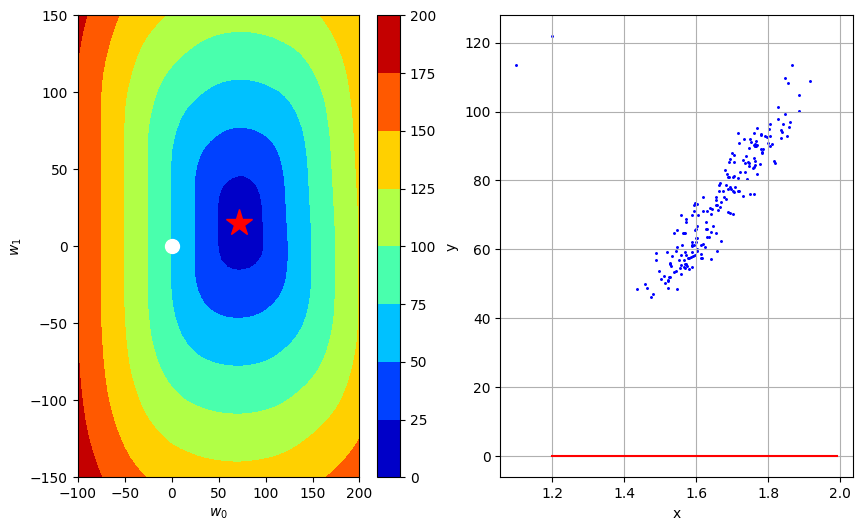

In [32]:
# Contour + trajectory view, on the MAE cost surface this time.
grid_losses_mae = np.zeros((len(grid_w0), len(grid_w1)))
for i, a in enumerate(grid_w0):
    for j, b in enumerate(grid_w1):
        grid_losses_mae[i, j] = compute_loss(y_o, tx_o, np.array([a, b]), "mae")

from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses_mae,
        grid_w0,
        grid_w1,
        mean_x_o,
        std_x_o,
        height_o,
        weight_o,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

**Exercise 6b:** plot the MAE model together with the two curves obtained in the previous exercise.

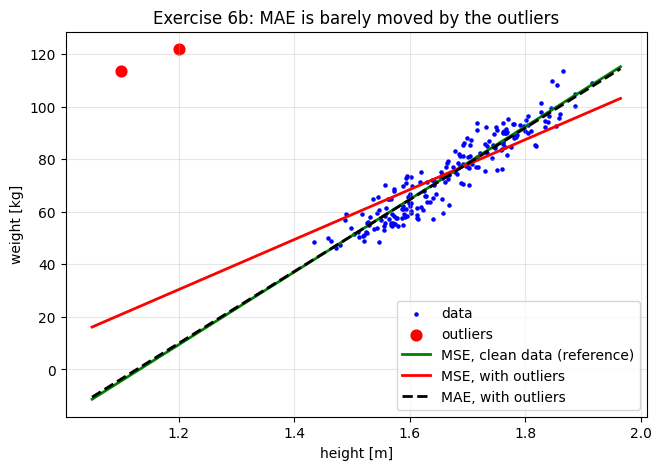

   MSE with outliers: mean |deviation| from the clean fit = 5.218 kg
   MAE with outliers: mean |deviation| from the clean fit = 0.296 kg


In [33]:
plot_fits(
    height_o,
    weight_o,
    [
        ("MSE, clean data (reference)", w_mse_clean, mean_x_s, std_x_s, "g-"),
        ("MSE, with outliers", w_mse_outlier, mean_x_o, std_x_o, "r-"),
        ("MAE, with outliers", w_mae_outlier, mean_x_o, std_x_o, "k--"),
    ],
    "Exercise 6b: MAE is barely moved by the outliers",
    outliers=2,
)

# How far is each fit from the reference (clean-data) line, in kg, over the data range?
grid_x = np.linspace(height_s.min(), height_s.max(), 200)
ref = w_mse_clean[0] + w_mse_clean[1] * (grid_x - mean_x_s) / std_x_s
for label, w, mean, std in [
    ("MSE with outliers", w_mse_outlier, mean_x_o, std_x_o),
    ("MAE with outliers", w_mae_outlier, mean_x_o, std_x_o),
]:
    line = w[0] + w[1] * (grid_x - mean) / std
    print(f"{label:>20}: mean |deviation| from the clean fit = "
          f"{np.mean(np.abs(line - ref)):.3f} kg")

### Exercise 6b — discussion

**Is the fit using MAE better than the one using MSE?** On this data set, yes — clearly. The MAE line with outliers nearly coincides with the MSE line fitted to the *clean* data (the deviations printed above are a fraction of a kg, against several kg for the MSE-with-outliers line). The reason is the one noted in 6a: in the subgradient each point contributes $\pm\tilde{\boldsymbol x}_n$, capped, however extreme its residual is, so the two mismeasured points get one vote each instead of a hundred.

"Better" is relative to what we want, though. If the large residuals were genuine signal rather than data-entry mistakes, downweighting them would be throwing away information — MSE is the maximum-likelihood cost under Gaussian noise, MAE under (heavier-tailed) Laplace noise. MAE also costs us the closed-form solution and the smoothness, which is what the rest of the exercise is about.

**Did the optimization ever encounter a non-differentiable point?** Essentially never, and the cell above counts it explicitly: it checks at every iterate whether any residual is *exactly* zero. Hitting $e_n = 0$ in floating point requires the line to pass exactly through a data point, which has probability zero for generic data. This is why subgradient descent is practical — the kinks exist and make the theory harder (no descent guarantee at every step, no vanishing gradient at the optimum), but the iterates almost surely never land on one. Our `np.sign` implementation would handle it correctly anyway.

A more visible consequence of non-smoothness: with a **constant** step size the subgradient never shrinks near the optimum (its norm stays $\approx \lVert\tilde{\boldsymbol x}\rVert$), so the iterates cannot settle — they orbit the minimum in a ball of radius $\sim\gamma$. That is why the run above uses the classic decreasing schedule $\gamma_t = \gamma/\sqrt{t+1}$. The cell below shows the difference.

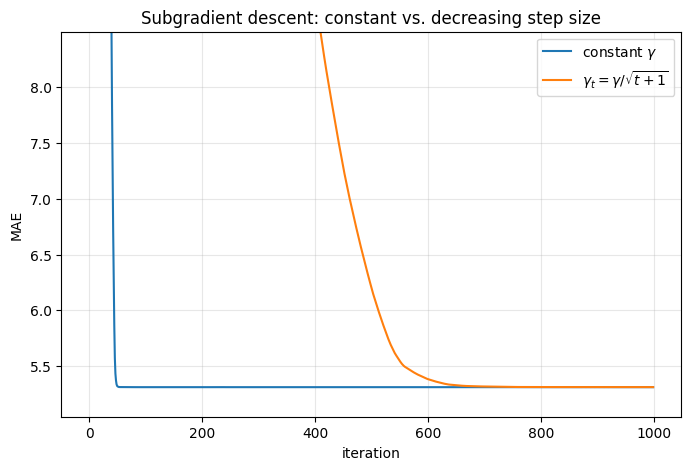

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
for decreasing in [False, True]:
    losses, _ = subgradient_descent(
        y_o, tx_o, np.array([0.0, 0.0]), 1000, 2.0,
        decreasing_gamma=decreasing, verbose=False,
    )
    label = r"$\gamma_t = \gamma/\sqrt{t+1}$" if decreasing else r"constant $\gamma$"
    ax.plot(losses, label=label)
ax.set_xlabel("iteration")
ax.set_ylabel("MAE")
best_mae = compute_loss(y_o, tx_o, w_mae_outlier, "mae")
ax.set_ylim(0.95 * best_mae, 1.6 * best_mae)
ax.set_title("Subgradient descent: constant vs. decreasing step size")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [35]:
def stochastic_subgradient_descent(
    y, tx, initial_w, batch_size, max_iters, gamma, decreasing_gamma=False, verbose=True
):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize
        decreasing_gamma: if True use the step size gamma / sqrt(t + 1)
        verbose: whether to print the loss and parameters at each iteration

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        for minibatch_y, minibatch_tx in batch_iter(y, tx, batch_size):
            loss = compute_loss(minibatch_y, minibatch_tx, w, loss_type="mae")
            subgradient = compute_subgradient_mae(minibatch_y, minibatch_tx, w)

            step = gamma / np.sqrt(n_iter + 1) if decreasing_gamma else gamma
            w = w - step * subgradient

            ws.append(w)
            losses.append(loss)

        if verbose:
            print(
                "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                    bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
                )
            )
    return losses, ws

In [36]:
# Define the parameters of the algorithm.
max_iters = 1000
gamma = 2.0
batch_size = 1

# Initialization
w_initial = np.array([0.0, 0.0])

# Start SubSGD.
np.random.seed(2)
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y_o, tx_o, w_initial, batch_size, max_iters, gamma, decreasing_gamma=True, verbose=False
)
end_time = datetime.datetime.now()

exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))
print("SubSGD fit: w0={:.4f}, w1={:.4f}".format(*subsgd_ws[-1]))
print("SubGD  fit: w0={:.4f}, w1={:.4f}".format(*w_mae_outlier))

SubSGD: execution time=0.016 seconds
SubSGD fit: w0=73.5262, w1=15.9302
SubGD  fit: w0=72.6825, w1=15.8495


interactive(children=(IntSlider(value=1, description='n_iter', max=1001, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_figure(n_iter)>

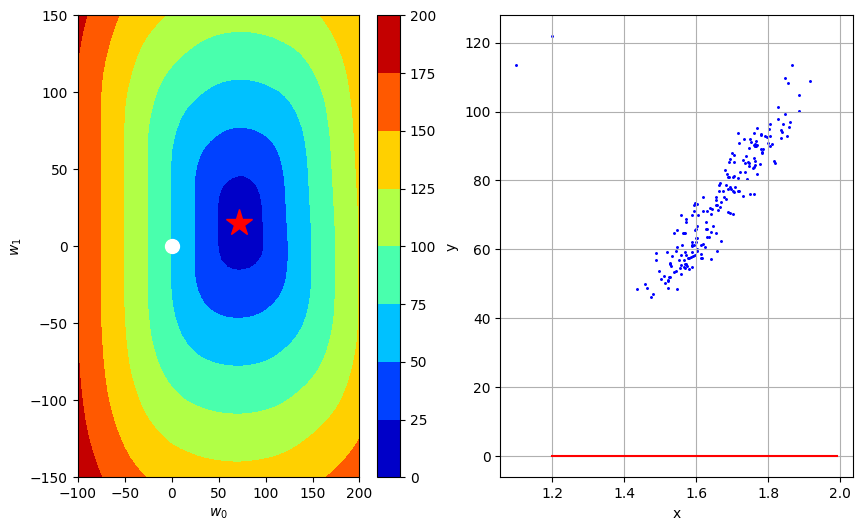

In [37]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses_mae,
        grid_w0,
        grid_w1,
        mean_x_o,
        std_x_o,
        height_o,
        weight_o,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))

**Exercise 6c:** compare the two algorithm variants on MAE with what we saw on MSE.

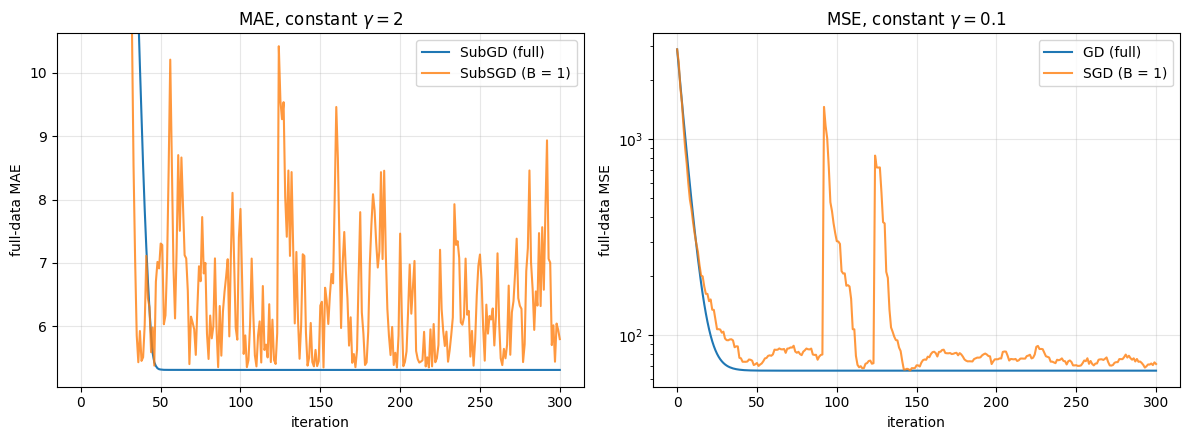

MAE  best achievable = 5.3112
     SubGD  (const gamma), last 50 iters = 5.3107
     SubSGD (const gamma), last 50 iters = 6.3922
MSE  best achievable = 65.9307
     GD     (const gamma), last 50 iters = 65.9307
     SGD    (const gamma), last 50 iters = 73.2235

mean single-sample update magnitude (B = 1):
   MAE, at the optimum: per-sample =   1.3461   full-batch =   0.0056
       MAE, 60 kg away: per-sample =   1.3461   full-batch =   1.0000
   MSE, at the optimum: per-sample =  11.8082   full-batch =   0.0000
       MSE, 60 kg away: per-sample =  84.0795   full-batch =  60.0000

spread of the last 50 constant-step SubGD iterates: [0.0155 0.0061]


In [38]:
max_iters = 300
w_initial = np.array([0.0, 0.0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# --- MAE: full subgradient vs. stochastic subgradient (constant step size) ---
_, w_full = subgradient_descent(y_o, tx_o, w_initial, max_iters, 2.0, verbose=False)
np.random.seed(2)
_, w_stoch = stochastic_subgradient_descent(
    y_o, tx_o, w_initial, 1, max_iters, 2.0, verbose=False
)
mae_full = [compute_loss(y_o, tx_o, w, "mae") for w in w_full]
mae_stoch = [compute_loss(y_o, tx_o, w, "mae") for w in w_stoch]
ax1.plot(mae_full, label="SubGD (full)")
ax1.plot(mae_stoch, label="SubSGD (B = 1)", alpha=0.8)
ax1.set_title(r"MAE, constant $\gamma = 2$")
ax1.set_ylabel("full-data MAE")
ax1.set_ylim(0.95 * best_mae, 2.0 * best_mae)

# --- MSE: full gradient vs. stochastic gradient, same picture for comparison ---
_, w_full_mse = gradient_descent(y_o, tx_o, w_initial, max_iters, 0.1, verbose=False)
np.random.seed(2)
_, w_stoch_mse = stochastic_gradient_descent(
    y_o, tx_o, w_initial, 1, max_iters, 0.1, verbose=False
)
mse_full = [compute_loss(y_o, tx_o, w) for w in w_full_mse]
mse_stoch = [compute_loss(y_o, tx_o, w) for w in w_stoch_mse]
ax2.plot(mse_full, label="GD (full)")
ax2.plot(mse_stoch, label="SGD (B = 1)", alpha=0.8)
ax2.set_yscale("log")
ax2.set_title(r"MSE, constant $\gamma = 0.1$")
ax2.set_ylabel("full-data MSE")

for ax in (ax1, ax2):
    ax.set_xlabel("iteration")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

# Where does each method settle? Average the loss over the last 50 iterates.
w_opt_o = np.linalg.solve(tx_o.T @ tx_o, tx_o.T @ y_o)
best_mse = compute_loss(y_o, tx_o, w_opt_o)

print(f"MAE  best achievable = {best_mae:.4f}")
print(f"     SubGD  (const gamma), last 50 iters = {np.mean(mae_full[-50:]):.4f}")
print(f"     SubSGD (const gamma), last 50 iters = {np.mean(mae_stoch[-50:]):.4f}")
print(f"MSE  best achievable = {best_mse:.4f}")
print(f"     GD     (const gamma), last 50 iters = {np.mean(mse_full[-50:]):.4f}")
print(f"     SGD    (const gamma), last 50 iters = {np.mean(mse_stoch[-50:]):.4f}")

# The crux: how big is a single-sample update, at the optimum vs. far from it?
print("\nmean single-sample update magnitude (B = 1):")
for name, w, grad_fn in [
    ("MAE, at the optimum", w_mae_outlier, compute_subgradient_mae),
    ("MAE, 60 kg away", w_mae_outlier - np.array([60.0, 0.0]), compute_subgradient_mae),
    ("MSE, at the optimum", w_opt_o, compute_gradient),
    ("MSE, 60 kg away", w_opt_o - np.array([60.0, 0.0]), compute_gradient),
]:
    per_sample = np.mean(
        [np.linalg.norm(grad_fn(y_o[n : n + 1], tx_o[n : n + 1], w)) for n in range(len(y_o))]
    )
    print(f"{name:>22}: per-sample = {per_sample:8.4f}   "
          f"full-batch = {np.linalg.norm(grad_fn(y_o, tx_o, w)):8.4f}")

# Does the constant-step SubGD actually settle, or does it orbit?
print("\nspread of the last 50 constant-step SubGD iterates:",
      np.array(w_full[-50:]).std(axis=0).round(4))

### Exercise 6c — how is the picture different from MSE?

**The broad pattern is the same as on MSE:** the full-batch method reaches the optimum and the $B=1$ stochastic one settles above it. With a constant step size, SubGD ends at MAE 5.311 against the 5.311 that is achievable, and the spread of its last 50 iterates is only ~0.015 — it really does settle. SubSGD ends around 6.39. On MSE the same experiment gives 65.93 (GD, exactly optimal) against 73.22 (SGD).

**What is genuinely different is that the noise never anneals.** Look at the single-sample update magnitudes printed above:

| | at the optimum | 60 kg away |
|---|---|---|
| MAE subgradient, $B=1$ | 1.346 | 1.346 |
| MSE gradient, $B=1$ | 11.81 | 84.08 |

The MAE subgradient of one sample is $\pm\tilde{\boldsymbol x}_n$ — its length does not depend on the residual at all, so it is *exactly* as large at the optimum as it is 60 kg away. Only the agreement of directions between samples changes. The MSE gradient of one sample is $e_n\tilde{\boldsymbol x}_n$, which shrinks by a factor of ~7 over the same approach, so SGD's steps partly anneal themselves. The consequence is that SubSGD's noise floor is relatively worse: it overshoots the optimum by ~20 % in loss, against ~11 % for SGD on MSE.

* **A decaying step size is therefore doing more work here.** $\gamma_t = \gamma/\sqrt{t+1}$ (used for the fits earlier in this section) is the only thing that shrinks the update near the optimum for MAE, since the subgradient will not do it. For MSE it is a refinement on top of an effect that already exists.
* **The same capping also makes the approach slower.** The *full* MAE subgradient is capped at $\approx 1$ however far away we are, so SubGD crawls toward the optimum at a near-constant $\gamma$ per step and needs tens of iterations just to travel from $w_0 = 0$ to $w_0 \approx 73$ — whereas MSE gradient descent, whose gradient grows with the distance, covers the same ground geometrically in a handful of steps. Bounded influence is exactly what buys the robustness in 6b, and it is also what costs the speed.
* **What is unchanged.** The stochastic variant is still far cheaper per iteration and makes just as much early progress, so per unit of work it remains the better deal.

# Wrap-Up

The code above is mirrored into plain `.py` files in this folder so it can be re-used later
(Project 1, subsequent labs) without going through the notebook:

| file | contents |
|---|---|
| `costs.py` | `compute_error`, `compute_mse`, `compute_mae`, `compute_loss` |
| `grid_search.py` | `generate_w`, `get_best_parameters`, `grid_search` |
| `gradient_descent.py` | `compute_gradient`, `gradient_descent` |
| `stochastic_gradient_descent.py` | `compute_stoch_gradient`, `stochastic_gradient_descent` |
| `subgradient_mae.py` | `compute_subgradient_mae`, `subgradient_descent`, `stochastic_subgradient_descent` |

The cell below imports them and checks that they reproduce the notebook results exactly —
run it after editing either copy, so the two cannot drift apart silently.

In [39]:
import costs
import gradient_descent as gd_mod
import grid_search as gs_mod
import stochastic_gradient_descent as sgd_mod
import subgradient_mae as subgd_mod

w_probe = np.array([42.0, -5.0])

# costs.py
assert np.isclose(costs.compute_loss(y, tx, w_probe), compute_loss(y, tx, w_probe))
assert np.isclose(
    costs.compute_loss(y, tx, w_probe, "mae"), compute_loss(y, tx, w_probe, "mae")
)

# grid_search.py
assert np.allclose(
    gs_mod.grid_search(y_s, tx_s, grid_w0_10, grid_w1_10),
    grid_search(y_s, tx_s, grid_w0_10, grid_w1_10),
)

# gradient_descent.py
assert np.allclose(gd_mod.compute_gradient(y, tx, w_probe), compute_gradient(y, tx, w_probe))
assert np.allclose(
    gd_mod.gradient_descent(y, tx, w_initial, 20, 0.3, verbose=False)[1][-1],
    gradient_descent(y, tx, w_initial, 20, 0.3, verbose=False)[1][-1],
)

# stochastic_gradient_descent.py
np.random.seed(7)
a = sgd_mod.stochastic_gradient_descent(y, tx, w_initial, 32, 20, 0.1, verbose=False)[1][-1]
np.random.seed(7)
b = stochastic_gradient_descent(y, tx, w_initial, 32, 20, 0.1, verbose=False)[1][-1]
assert np.allclose(a, b)

# subgradient_mae.py
assert np.allclose(
    subgd_mod.compute_subgradient_mae(y_o, tx_o, w_probe),
    compute_subgradient_mae(y_o, tx_o, w_probe),
)
assert np.allclose(
    subgd_mod.subgradient_descent(y_o, tx_o, w_initial, 50, 2.0, verbose=False)[1][-1],
    subgradient_descent(y_o, tx_o, w_initial, 50, 2.0, verbose=False)[1][-1],
)

print("All modules agree with the notebook implementations.")

All modules agree with the notebook implementations.
